--- DIMENSIONALIDAD ---
Filas: 4000, Columnas: 14

--- ANÁLISIS DE TIPADO ---
gender                             int64
nearLocation                       int64
partner                            int64
promoFriends                       int64
phone                              int64
contractPeriod                     int64
groupVisits                        int64
age                                int64
avgAdditionalChargesTotal        float64
monthToEndContract                 int64
lifetime                           int64
avgClassFrequencyTotal           float64
avgClassFrequencyCurrentMonth    float64
churn                              int64
dtype: object

--- CONTROL DE CALIDAD ---
Valores Nulos: 0
Registros Duplicados: 0

--- RESUMEN ESTADÍSTICO ---
                                     mean      median        mode        std  \
gender                           0.510250    1.000000    1.000000   0.499957   
nearLocation                     0.845250    1.000000    1.000000   0.361711

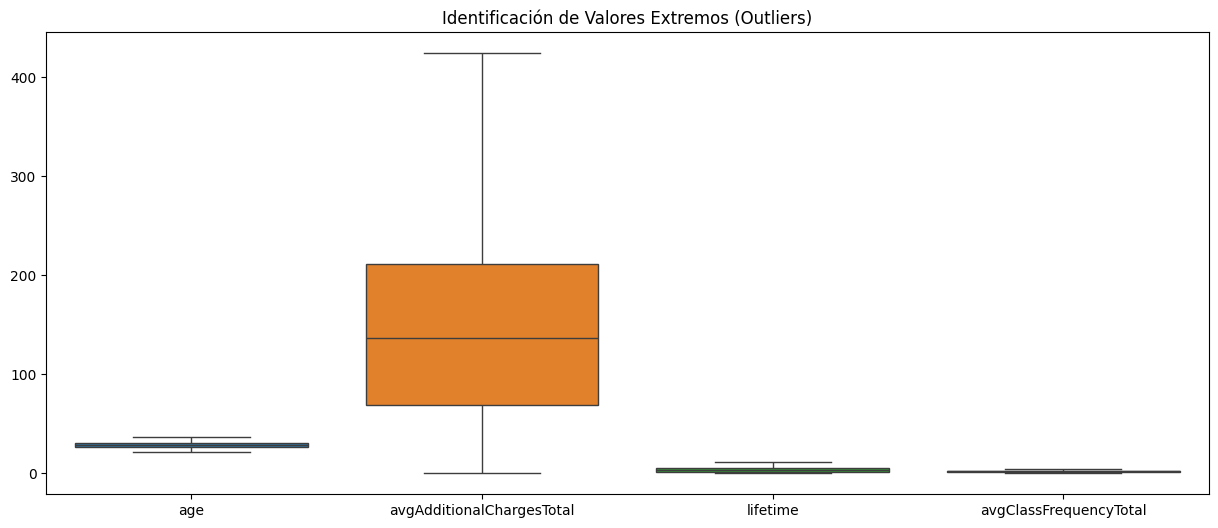

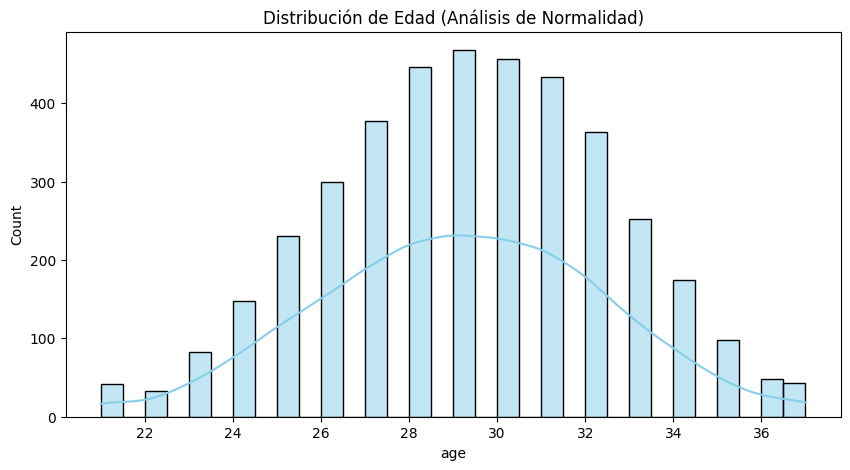


--- BALANCE DE LA VARIABLE OBJETIVO (CHURN) ---
churn
0    73.475
1    26.525
Name: proportion, dtype: float64


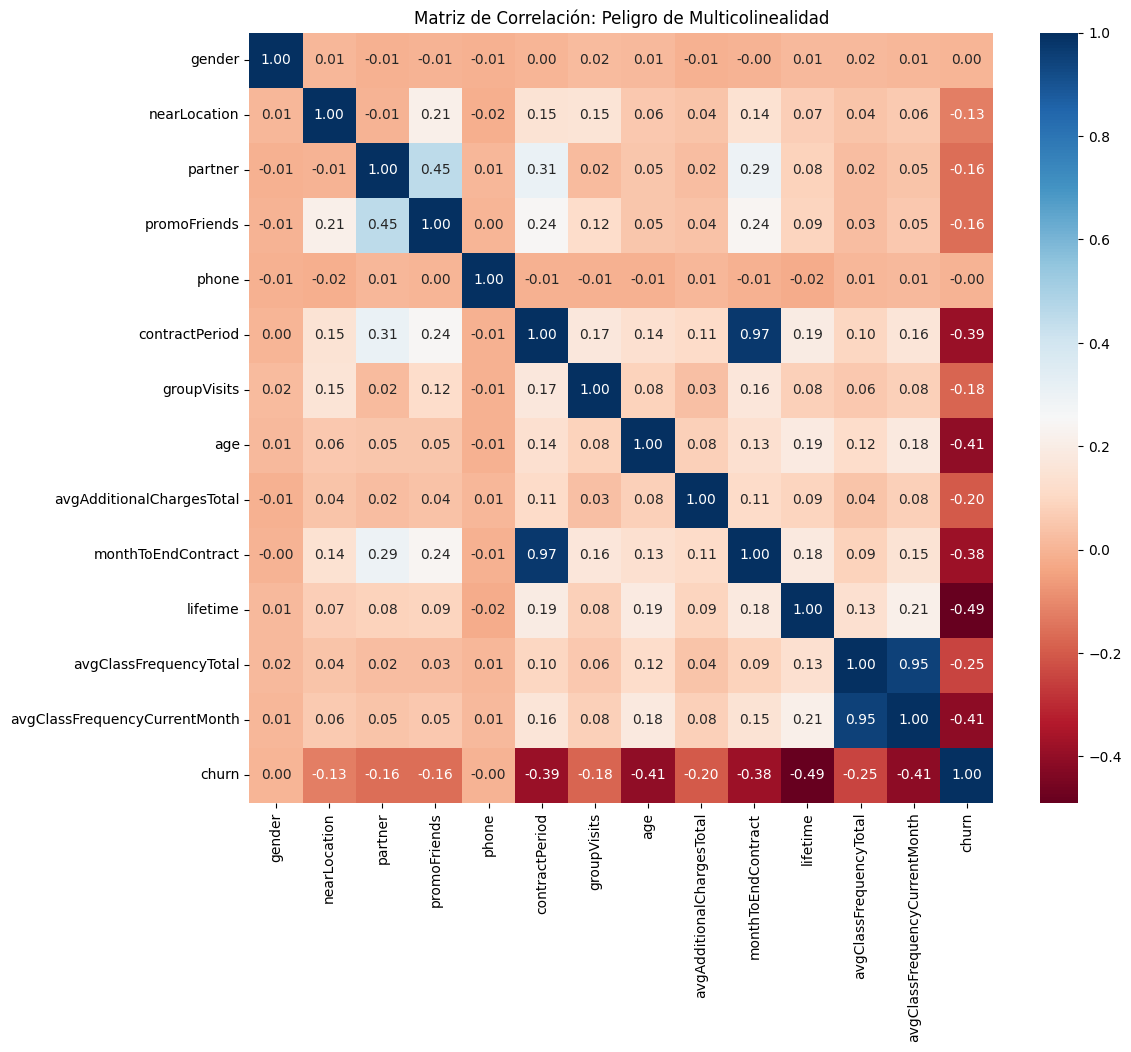


--- EJECUTANDO SANITY CHECK ---
Nulos: ✅ PASÓ
Rango Edad Coherente: ✅ PASÓ
Churn Binario: ✅ PASÓ
Lifetime Positivo: ✅ PASÓ

Archivo 'datos_sinteticos_gym.csv' creado con éxito.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

# =================================================================
# 1. CARGA Y ANÁLISIS DE ESTRUCTURA (Inspección Ocular Digital)
# =================================================================
df = pd.read_csv('gym_churn_cleaned.csv')

print("--- DIMENSIONALIDAD ---")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\n--- ANÁLISIS DE TIPADO ---")
# Verificamos si las categorías están como object o si ya fueron codificadas
print(df.dtypes)

# =================================================================
# 2. LIMPIEZA Y CALIDAD (Evitar "Garbage In, Garbage Out")
# =================================================================
print("\n--- CONTROL DE CALIDAD ---")
nulos = df.isnull().sum().sum()
duplicados = df.duplicated().sum()
print(f"Valores Nulos: {nulos}")
print(f"Registros Duplicados: {duplicados}")

# =================================================================
# 3. ESTADÍSTICA DESCRIPTIVA (Tendencia y Dispersión)
# =================================================================
stats_summary = df.describe().T
stats_summary['median'] = df.median()
stats_summary['mode'] = df.mode().iloc[0]
stats_summary['skewness'] = df.skew() # Medida de sesgo

print("\n--- RESUMEN ESTADÍSTICO ---")
print(stats_summary[['mean', 'median', 'mode', 'std', 'skewness']])

# =================================================================
# 4. DETECCIÓN DE OUTLIERS (Boxplots)
# =================================================================
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[['age', 'avgAdditionalChargesTotal', 'lifetime', 'avgClassFrequencyTotal']])
plt.title("Identificación de Valores Extremos (Outliers)")
plt.show()

# =================================================================
# 5. ANÁLISIS UNIVARIADO (Distribuciones y Desbalanceo)
# =================================================================
# Histograma de Edad para ver si es una Campana de Gauss
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], kde=True, color='skyblue')
plt.title("Distribución de Edad (Análisis de Normalidad)")
plt.show()

# Conteo de categorías para detectar desbalanceo en Churn
print("\n--- BALANCE DE LA VARIABLE OBJETIVO (CHURN) ---")
print(df['churn'].value_counts(normalize=True) * 100)

# =================================================================
# 6. ANÁLISIS MULTIVARIADO (Correlación y Multicolinealidad)
# =================================================================
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f")
plt.title("Matriz de Correlación: Peligro de Multicolinealidad")
plt.show()

#

# Scatter Plot: Relación de Gastos vs Edad segmentado por Churn
fig = px.scatter(df, x="age", y="avgAdditionalChargesTotal", color="churn",
                 title="Dispersión: Edad vs Gastos Extra (Variable Objetivo)")
fig.show()

# =================================================================
# 7. SCRIPT DE SANITY CHECK (Validación Automática)
# =================================================================
def sanity_check(data):
    print("\n--- EJECUTANDO SANITY CHECK ---")
    tests = {
        "Nulos": data.isnull().sum().sum() == 0,
        "Rango Edad Coherente": data['age'].between(16, 90).all(),
        "Churn Binario": set(data['churn'].unique()) == {0, 1},
        "Lifetime Positivo": (data['lifetime'] >= 0).all()
    }
    for test, result in tests.items():
        print(f"{test}: {'✅ PASÓ' if result else '❌ FALLÓ'}")

sanity_check(df)

# =================================================================
# 8. GENERACIÓN DE DATOS SINTÉTICOS (Para Pruebas)
# =================================================================
def generate_synthetic(n=50):
    synthetic = df.sample(n).copy()
    # Añadimos un poco de ruido aleatorio a los cargos adicionales
    synthetic['avgAdditionalChargesTotal'] = synthetic['avgAdditionalChargesTotal'] * np.random.uniform(0.8, 1.2)
    return synthetic

df_sintetico = generate_synthetic()
df_sintetico.to_csv('datos_sinteticos_gym.csv', index=False)
print("\nArchivo 'datos_sinteticos_gym.csv' creado con éxito.")